# Лабораторная работа №3
## Обучение с учителем. Задача классификации

**Датасет:** Diabetes Health Indicators  
**Целевая переменная:** `Diabetes_012` — статус диабета у пациента (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа)  
**Тип задачи:** Мультиклассовая классификация (3 класса)


## 1. Загрузка библиотек

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Sklearn — разбиение данных
from sklearn.model_selection import (
    train_test_split, KFold, cross_val_score,
    GridSearchCV, RandomizedSearchCV
)

# Sklearn — классификаторы
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Sklearn — метрики
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report,
    roc_auc_score, roc_curve
)

# Балансировка классов
from imblearn.over_sampling import SMOTE

# Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Пользовательские модули (разработаны в ЛР №2 и ЛР №3)
import sys
sys.path.insert(0, '.')
from custom_metrics import (
    custom_accuracy, custom_precision,
    custom_recall, custom_f1, custom_confusion_matrix
)
from custom_knn import CustomKNNClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Все библиотеки успешно загружены.')

Все библиотеки успешно загружены.


## 2. Загрузка и подготовка данных

### 2.1. Загрузка датасета

In [3]:
data = pd.read_csv('../datasets/diabetes_health_indicators.csv')
data

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0000,1.0000,1.0000,1.0000,40.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,5.0000,18.0000,15.0000,1.0000,0.0000,9.0000,4.0000,3.0000
1,0.0000,0.0000,0.0000,0.0000,25.0000,1.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,3.0000,0.0000,0.0000,0.0000,0.0000,7.0000,6.0000,1.0000
2,0.0000,1.0000,1.0000,1.0000,28.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,0.0000,9.0000,4.0000,8.0000
3,0.0000,1.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,11.0000,3.0000,6.0000
4,0.0000,1.0000,1.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,3.0000,0.0000,0.0000,0.0000,11.0000,5.0000,4.0000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
253675,0.0000,1.0000,1.0000,1.0000,45.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,3.0000,0.0000,5.0000,0.0000,1.0000,5.0000,6.0000,7.0000
253676,2.0000,1.0000,1.0000,1.0000,18.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,4.0000,0.0000,0.0000,1.0000,0.0000,11.0000,2.0000,4.0000
253677,0.0000,0.0000,0.0000,1.0000,28.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,2.0000,5.0000,2.0000
253678,0.0000,1.0000,0.0000,1.0000,23.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,0.0000,1.0000,0.0000,3.0000,0.0000,0.0000,0.0000,1.0000,7.0000,5.0000,1.0000


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 253680 entries, 0 to 253679
Data columns (total 22 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   Diabetes_012          253680 non-null  float64
 1   HighBP                253680 non-null  float64
 2   HighChol              253680 non-null  float64
 3   CholCheck             253680 non-null  float64
 4   BMI                   253680 non-null  float64
 5   Smoker                253680 non-null  float64
 6   Stroke                253680 non-null  float64
 7   HeartDiseaseorAttack  253680 non-null  float64
 8   PhysActivity          253680 non-null  float64
 9   Fruits                253680 non-null  float64
 10  Veggies               253680 non-null  float64
 11  HvyAlcoholConsump     253680 non-null  float64
 12  AnyHealthcare         253680 non-null  float64
 13  NoDocbcCost           253680 non-null  float64
 14  GenHlth               253680 non-null  float64
 15  MentHlth   

In [5]:
data.describe()

,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
count,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000,253680.0000
mean,0.2969,0.4290,0.4241,0.9627,28.3824,0.4432,0.0406,0.0942,0.7565,0.6343,0.8114,0.0562,0.9511,0.0842,2.5114,3.1848,4.2421,0.1682,0.4403,8.0321,5.0504,6.0539
std,0.6982,0.4949,0.4942,0.1896,6.6087,0.4968,0.1973,0.2921,0.4292,0.4816,0.3912,0.2303,0.2158,0.2777,1.0685,7.4128,8.7180,0.3741,0.4964,3.0542,0.9858,2.0711
min,0.0000,0.0000,0.0000,0.0000,12.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,1.0000,0.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000
25%,0.0000,0.0000,0.0000,1.0000,24.0000,0.0000,0.0000,0.0000,1.0000,0.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,6.0000,4.0000,5.0000
50%,0.0000,0.0000,0.0000,1.0000,27.0000,0.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,2.0000,0.0000,0.0000,0.0000,0.0000,8.0000,5.0000,7.0000
75%,0.0000,1.0000,1.0000,1.0000,31.0000,1.0000,0.0000,0.0000,1.0000,1.0000,1.0000,0.0000,1.0000,0.0000,3.0000,2.0000,3.0000,0.0000,1.0000,10.0000,6.0000,8.0000
max,2.0000,1.0000,1.0000,1.0000,98.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,1.0000,5.0000,30.0000,30.0000,1.0000,1.0000,13.0000,6.0000,8.0000


### 2.2. Выделение целевого признака и предикторов

Целевой признак — `Diabetes_012` (0 — нет диабета, 1 — предиабет, 2 — диабет 2 типа).  
Тип задачи: **мультиклассовая классификация** (3 класса).


In [6]:
y = data['Diabetes_012']
X = data.drop(columns=['Diabetes_012'])

print(f'Размер матрицы признаков X: {X.shape}')
print(f'Размер вектора меток y:     {y.shape}')
print()
print('Целевой признак — Diabetes_012:')
print(y.value_counts().rename(index={0: 'Нет диабета (0)', 1: 'Предиабет (1)', 2: 'Диабет 2 типа (2)'}))
print()
print('Предикторы:', list(X.columns))

Размер матрицы признаков X: (253680, 21)
Размер вектора меток y:     (253680,)

Целевой признак — Diabetes_012:
Diabetes_012
Нет диабета (0)      213703
Диабет 2 типа (2)     35346
Предиабет (1)          4631
Name: count, dtype: int64

Предикторы: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### 2.3. Проверка и устранение дисбаланса классов

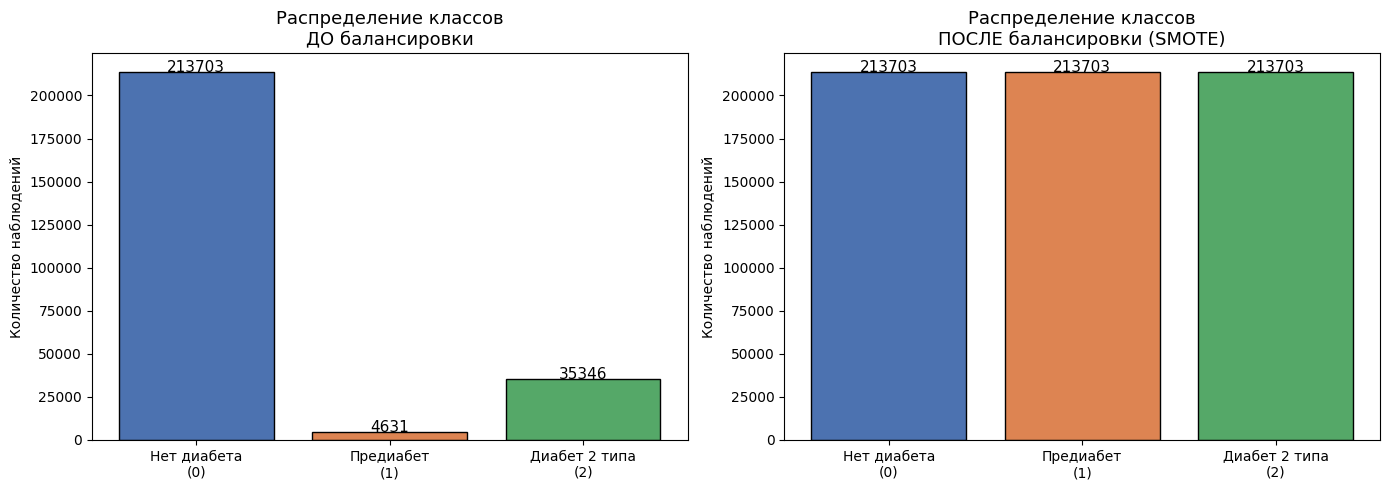

Количество наблюдений ДО балансировки:
Diabetes_012
Нет диабета (0)      213703
Предиабет (1)          4631
Диабет 2 типа (2)     35346
Name: count, dtype: int64

Количество наблюдений ПОСЛЕ балансировки (SMOTE):
Diabetes_012
Нет диабета (0)      213703
Предиабет (1)        213703
Диабет 2 типа (2)    213703
Name: count, dtype: int64


In [7]:
counts = y.value_counts().sort_index()
labels = ['Нет диабета\n(0)', 'Предиабет\n(1)', 'Диабет 2 типа\n(2)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# До балансировки
axes[0].bar(labels, counts.values, color=['#4c72b0','#dd8452','#55a868'], edgecolor='black')
axes[0].set_title('Распределение классов\nДО балансировки', fontsize=13)
axes[0].set_ylabel('Количество наблюдений')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=11)

# SMOTE балансировка
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X_scaled, y)

counts_bal = pd.Series(y_balanced).value_counts().sort_index()
axes[1].bar(labels, counts_bal.values, color=['#4c72b0','#dd8452','#55a868'], edgecolor='black')
axes[1].set_title('Распределение классов\nПОСЛЕ балансировки (SMOTE)', fontsize=13)
axes[1].set_ylabel('Количество наблюдений')
for i, v in enumerate(counts_bal.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('class_balance.png', dpi=100, bbox_inches='tight')
plt.show()

print('Количество наблюдений ДО балансировки:')
print(counts.rename(index={0:'Нет диабета (0)', 1:'Предиабет (1)', 2:'Диабет 2 типа (2)'}))
print()
print('Количество наблюдений ПОСЛЕ балансировки (SMOTE):')
print(counts_bal.rename(index={0:'Нет диабета (0)', 1:'Предиабет (1)', 2:'Диабет 2 типа (2)'}))

**Вывод:** В исходном датасете наблюдается выраженный дисбаланс классов — класс «Нет диабета» значительно превалирует над остальными.  
Для устранения дисбаланса применён метод **SMOTE** (Synthetic Minority Over-sampling Technique), который генерирует синтетические примеры для классов меньшинства путём интерполяции между существующими наблюдениями.  
После балансировки все три класса представлены равным числом наблюдений, что предотвратит смещение модели в сторону преобладающего класса.


### 2.4. Разделение данных на обучающую и тестовую выборки

#### Метод отложенной выборки (Hold-out) со стратификацией

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced,
    test_size=0.2,
    random_state=42,
    stratify=y_balanced   # стратификация сохраняет пропорции классов
)

print(f'Размер обучающей выборки: {X_train.shape}')
print(f'Размер тестовой выборки:  {X_test.shape}')
print()
print('Доля классов в обучающей выборке:')
print(pd.Series(y_train).value_counts(normalize=True).sort_index().round(4))
print()
print('Доля классов в тестовой выборке:')
print(pd.Series(y_test).value_counts(normalize=True).sort_index().round(4))

Размер обучающей выборки: (512887, 21)
Размер тестовой выборки:  (128222, 21)

Доля классов в обучающей выборке:
Diabetes_012
0.0000   0.3333
1.0000   0.3333
2.0000   0.3333
Name: proportion, dtype: float64

Доля классов в тестовой выборке:
Diabetes_012
0.0000   0.3333
1.0000   0.3333
2.0000   0.3333
Name: proportion, dtype: float64


#### Метод k-fold (кросс-валидация)

In [9]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print('Метод k-fold (k=5) будет применён при оценке моделей.')
print(f'Количество фолдов: {kf.n_splits}')
fold_sizes = [len(val_idx) for _, val_idx in kf.split(X_balanced)]
print(f'Размеры валидационных фолдов: {fold_sizes}')

Метод k-fold (k=5) будет применён при оценке моделей.
Количество фолдов: 5
Размеры валидационных фолдов: [128222, 128222, 128222, 128222, 128221]


## 3. Решение задачи классификации

### 3.1. Logistic Regression

In [10]:
lr = LogisticRegression(max_iter=1000, random_state=42, multi_class='auto')
lr.fit(X_train, y_train)

y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test  = lr.predict(X_test)

print('=== Logistic Regression ===')
print('\nОтчёт на тестовой выборке:')
print(classification_report(y_test, y_pred_lr_test,
      target_names=['Нет диабета (0)', 'Предиабет (1)', 'Диабет 2 типа (2)']))

TypeError: LogisticRegression.__init__() got an unexpected keyword argument 'multi_class'

### 3.2. kNN — исследование метрик расстояния и влияния k

In [ ]:
# Исследование влияния k на точность
k_values = range(1, 31)
train_acc, test_acc = [], []

for k in k_values:
    knn_tmp = KNeighborsClassifier(n_neighbors=k)
    knn_tmp.fit(X_train, y_train)
    train_acc.append(accuracy_score(y_train, knn_tmp.predict(X_train)))
    test_acc.append(accuracy_score(y_test,  knn_tmp.predict(X_test)))

plt.figure(figsize=(12, 5))
plt.plot(k_values, train_acc, 'o-', label='Train Accuracy', color='#4c72b0')
plt.plot(k_values, test_acc,  's-', label='Test Accuracy',  color='#dd8452')
plt.xlabel('Количество соседей k', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Влияние гиперпараметра k на точность модели kNN', fontsize=13)
plt.legend()
plt.grid(alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.savefig('knn_k_effect.png', dpi=100, bbox_inches='tight')
plt.show()

best_k = k_values[np.argmax(test_acc)]
print(f'Оптимальное k по тестовой выборке: {best_k} (Accuracy = {max(test_acc):.4f})')

In [ ]:
# Исследование метрик расстояния
metrics_to_test = ['euclidean', 'manhattan', 'chebyshev', 'minkowski']
print('Влияние метрики расстояния на точность kNN (k=5):')
print(f'{'Метрика':<15} {'Train Accuracy':<18} {'Test Accuracy':<15}')
print('-' * 50)
for m in metrics_to_test:
    knn_m = KNeighborsClassifier(n_neighbors=5, metric=m)
    knn_m.fit(X_train, y_train)
    tr = accuracy_score(y_train, knn_m.predict(X_train))
    te = accuracy_score(y_test,  knn_m.predict(X_test))
    print(f'{m:<15} {tr:<18.4f} {te:<15.4f}')

In [ ]:
# Итоговая модель kNN с лучшими параметрами
knn = KNeighborsClassifier(n_neighbors=best_k, metric='euclidean')
knn.fit(X_train, y_train)

y_pred_knn_train = knn.predict(X_train)
y_pred_knn_test  = knn.predict(X_test)

print(f'=== kNN (k={best_k}, metric=euclidean) ===')
print('\nОтчёт на тестовой выборке:')
print(classification_report(y_test, y_pred_knn_test,
      target_names=['Нет диабета (0)', 'Предиабет (1)', 'Диабет 2 типа (2)']))

### 3.3. Naive Bayes

In [ ]:
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb_train = nb.predict(X_train)
y_pred_nb_test  = nb.predict(X_test)

print('=== Naive Bayes (GaussianNB) ===')
print('\nОтчёт на тестовой выборке:')
print(classification_report(y_test, y_pred_nb_test,
      target_names=['Нет диабета (0)', 'Предиабет (1)', 'Диабет 2 типа (2)']))

### 3.4. SVM с различными ядерными функциями

In [ ]:
svm_kernels = {
    'Linear Kernel':      SVC(kernel='linear',  C=1, probability=True, random_state=42),
    'Polynomial Kernel':  SVC(kernel='poly',     C=1, degree=3, probability=True, random_state=42),
    'RBF Kernel':         SVC(kernel='rbf',      C=1, probability=True, random_state=42),
    'Sigmoid Kernel':     SVC(kernel='sigmoid',  C=1, probability=True, random_state=42),
}

svm_results = {}
print('Результаты SVM с различными ядрами:')
print(f'{'Ядро':<25} {'Train Acc':<12} {'Test Acc':<12}')
print('-' * 50)
for name, clf in svm_kernels.items():
    clf.fit(X_train, y_train)
    tr = accuracy_score(y_train, clf.predict(X_train))
    te = accuracy_score(y_test,  clf.predict(X_test))
    svm_results[name] = {'clf': clf, 'train_acc': tr, 'test_acc': te}
    print(f'{name:<25} {tr:<12.4f} {te:<12.4f}')

best_svm_name = max(svm_results, key=lambda k: svm_results[k]['test_acc'])
print(f'\nЛучшее SVM ядро: {best_svm_name} (Test Acc = {svm_results[best_svm_name]["test_acc"]:.4f})')
svm_best = svm_results[best_svm_name]['clf']
y_pred_svm_train = svm_best.predict(X_train)
y_pred_svm_test  = svm_best.predict(X_test)

## 4. Подбор гиперпараметров

### 4.1. GridSearchCV — Logistic Regression

In [ ]:
param_grid_lr = {'C': [0.01, 0.1, 1, 10, 100]}
gs_lr = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42),
    param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1
)
gs_lr.fit(X_train, y_train)
print(f'GridSearchCV — Logistic Regression')
print(f'Лучшие параметры: {gs_lr.best_params_}')
print(f'Лучшая Accuracy (CV): {gs_lr.best_score_:.4f}')
lr = gs_lr.best_estimator_
y_pred_lr_train = lr.predict(X_train)
y_pred_lr_test  = lr.predict(X_test)

### 4.2. RandomizedSearchCV — kNN

In [ ]:
param_dist_knn = {'n_neighbors': range(1, 30), 'metric': ['euclidean', 'manhattan', 'chebyshev']}
rs_knn = RandomizedSearchCV(
    KNeighborsClassifier(), param_dist_knn,
    n_iter=20, cv=5, scoring='accuracy', random_state=42, n_jobs=-1
)
rs_knn.fit(X_train, y_train)
print(f'RandomizedSearchCV — kNN')
print(f'Лучшие параметры: {rs_knn.best_params_}')
print(f'Лучшая Accuracy (CV): {rs_knn.best_score_:.4f}')
knn = rs_knn.best_estimator_
y_pred_knn_train = knn.predict(X_train)
y_pred_knn_test  = knn.predict(X_test)

### 4.3. Optuna — SVM (RBF Kernel)

In [ ]:
def objective_svm(trial):
    C     = trial.suggest_float('C', 1e-2, 1e2, log=True)
    gamma = trial.suggest_categorical('gamma', ['scale', 'auto'])
    clf = SVC(kernel='rbf', C=C, gamma=gamma, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=3, scoring='accuracy')
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective_svm, n_trials=30)
best_svm_params = study.best_params
print(f'Optuna — SVM (RBF)')
print(f'Лучшие параметры: {best_svm_params}')
print(f'Лучшая Accuracy (CV): {study.best_value:.4f}')

svm_opt = SVC(kernel='rbf', probability=True, random_state=42, **best_svm_params)
svm_opt.fit(X_train, y_train)
y_pred_svm_train = svm_opt.predict(X_train)
y_pred_svm_test  = svm_opt.predict(X_test)

## 5. Визуализация результатов классификации

### 5.1. Матрицы ошибок для всех классификаторов

In [ ]:
clf_preds = {
    'Logistic Regression': (y_pred_lr_test,),
    'kNN':                 (y_pred_knn_test,),
    'Naive Bayes':         (y_pred_nb_test,),
    f'SVM (RBF)':          (y_pred_svm_test,),
}

class_names = ['Нет диабета\n(0)', 'Предиабет\n(1)', 'Диабет 2 типа\n(2)']

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (name, (y_p,)) in zip(axes, clf_preds.items()):
    cm = confusion_matrix(y_test, y_p)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=class_names, yticklabels=class_names)
    ax.set_title(f'{name}\nAccuracy = {accuracy_score(y_test, y_p):.4f}', fontsize=12)
    ax.set_xlabel('Предсказанный класс')
    ax.set_ylabel('Истинный класс')

plt.suptitle('Матрицы ошибок классификаторов', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=100, bbox_inches='tight')
plt.show()

**Пояснение ошибок первого и второго рода:**

- **Ошибка первого рода (False Positive, FP)** — модель предсказывает наличие диабета/предиабета, тогда как у пациента его нет. В медицинском контексте это приводит к излишнему беспокойству пациента и дополнительным обследованиям.
- **Ошибка второго рода (False Negative, FN)** — модель предсказывает отсутствие диабета, тогда как он есть. Это более опасная ошибка: пациент с диабетом не получит своевременного лечения.

В задачах медицинской диагностики ошибка второго рода, как правило, считается более критичной, поэтому при выборе модели следует уделять особое внимание метрике **Recall** для классов 1 и 2.


### 5.2. ROC-кривые (для каждого класса по схеме One-vs-Rest)

In [ ]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0, 1, 2])
class_labels = ['Нет диабета (0)', 'Предиабет (1)', 'Диабет 2 типа (2)']
colors = ['#4c72b0', '#dd8452', '#55a868']

clfs_roc = {
    'Logistic Regression': lr,
    'kNN':                 knn,
    'Naive Bayes':         nb,
    'SVM (RBF)':           svm_opt,
}

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes = axes.flatten()

for ax, (clf_name, clf) in zip(axes, clfs_roc.items()):
    if hasattr(clf, 'predict_proba'):
        y_score = clf.predict_proba(X_test)
    else:
        y_score = clf.decision_function(X_test)
        # нормализация для OvR
        from sklearn.preprocessing import MinMaxScaler
        y_score = MinMaxScaler().fit_transform(y_score)

    for i, (label, color) in enumerate(zip(class_labels, colors)):
        if y_score.shape[1] > i:
            fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
            auc = roc_auc_score(y_test_bin[:, i], y_score[:, i])
            ax.plot(fpr, tpr, color=color, lw=2, label=f'{label} (AUC = {auc:.3f})')

    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC-кривая: {clf_name}', fontsize=11)
    ax.legend(loc='lower right', fontsize=9)
    ax.grid(alpha=0.3)

plt.suptitle('ROC-кривые для всех классификаторов (One-vs-Rest)', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=100, bbox_inches='tight')
plt.show()

## 6. Реализация пользовательских функций

Пользовательские функции метрик реализованы в файле `custom_metrics.py`.  
Ниже выполняется сравнение результатов с реализацией Scikit-learn.


In [ ]:
print('=== Сравнение пользовательских метрик с Scikit-learn ===')
print()
print(f'{'Метрика':<15} {'Sklearn':<12} {'Custom':<12} {'Совпадение':<10}')
print('-' * 52)

metrics_compare = {
    'Accuracy':  (accuracy_score(y_test, y_pred_lr_test),
                  custom_accuracy(y_test, y_pred_lr_test)),
    'Precision': (precision_score(y_test, y_pred_lr_test, average='macro'),
                  custom_precision(y_test, y_pred_lr_test, average='macro')),
    'Recall':    (recall_score(y_test, y_pred_lr_test, average='macro'),
                  custom_recall(y_test, y_pred_lr_test, average='macro')),
    'F1':        (f1_score(y_test, y_pred_lr_test, average='macro'),
                  custom_f1(y_test, y_pred_lr_test, average='macro')),
}

for name, (sk_val, cu_val) in metrics_compare.items():
    match = '✓' if abs(sk_val - cu_val) < 1e-10 else '≈'
    print(f'{name:<15} {sk_val:<12.4f} {cu_val:<12.4f} {match:<10}')

print()
print('--- Матрица ошибок (Sklearn) ---')
print(confusion_matrix(y_test, y_pred_lr_test))
print()
print('--- Матрица ошибок (Custom) ---')
print(custom_confusion_matrix(y_test, y_pred_lr_test))

## 7. Реализация алгоритма классификатора kNN

Пользовательский классификатор kNN реализован в файле `custom_knn.py`.  
Ниже выполняется сравнение его производительности с эталонным `KNeighborsClassifier` из Scikit-learn.


In [ ]:
# Используем небольшую подвыборку для ускорения работы программного kNN
from sklearn.model_selection import train_test_split as tts

sample_size = 2000
idx = np.random.RandomState(42).choice(len(X_train), sample_size, replace=False)
X_tr_s = X_train[idx]
y_tr_s = np.array(y_train)[idx]

best_k_val = knn.get_params()['n_neighbors']

# Sklearn kNN
sklearn_knn = KNeighborsClassifier(n_neighbors=best_k_val, metric='euclidean')
sklearn_knn.fit(X_tr_s, y_tr_s)

# Custom kNN
custom_knn_clf = CustomKNNClassifier(n_neighbors=best_k_val, metric='euclidean')
custom_knn_clf.fit(X_tr_s, y_tr_s)

# Предсказания на тестовой выборке
y_pred_sk_train = sklearn_knn.predict(X_tr_s)
y_pred_sk_test  = sklearn_knn.predict(X_test)

y_pred_cu_train = custom_knn_clf.predict(X_tr_s)
y_pred_cu_test  = custom_knn_clf.predict(X_test)

def get_metrics(y_true_train, y_pred_train, y_true_test, y_pred_test):
    return {
        'Train F1':        f1_score(y_true_train, y_pred_train, average='macro'),
        'Train Accuracy':  accuracy_score(y_true_train, y_pred_train),
        'Train Precision': precision_score(y_true_train, y_pred_train, average='macro'),
        'Train Recall':    recall_score(y_true_train, y_pred_train, average='macro'),
        'Test F1':         f1_score(y_true_test, y_pred_test, average='macro'),
        'Test Accuracy':   accuracy_score(y_true_test, y_pred_test),
        'Test Precision':  precision_score(y_true_test, y_pred_test, average='macro'),
        'Test Recall':     recall_score(y_true_test, y_pred_test, average='macro'),
    }

sk_metrics = get_metrics(y_tr_s, y_pred_sk_train, y_test, y_pred_sk_test)
cu_metrics = get_metrics(y_tr_s, y_pred_cu_train, y_test, y_pred_cu_test)

knn_comparison = pd.DataFrame({
    'kNN из Sklearn':  sk_metrics,
    'Программный kNN': cu_metrics,
}).T

# Переименование колонок для Образца 1
knn_table = pd.DataFrame({
    'Классификатор': ['kNN из Sklearn', 'Программный kNN'],
    'Train F1':        [sk_metrics['Train F1'],        cu_metrics['Train F1']],
    'Train Accuracy':  [sk_metrics['Train Accuracy'],  cu_metrics['Train Accuracy']],
    'Train Precision': [sk_metrics['Train Precision'], cu_metrics['Train Precision']],
    'Train Recall':    [sk_metrics['Train Recall'],    cu_metrics['Train Recall']],
    'Test F1':         [sk_metrics['Test F1'],         cu_metrics['Test F1']],
    'Test Accuracy':   [sk_metrics['Test Accuracy'],   cu_metrics['Test Accuracy']],
    'Test Precision':  [sk_metrics['Test Precision'],  cu_metrics['Test Precision']],
    'Test Recall':     [sk_metrics['Test Recall'],     cu_metrics['Test Recall']],
})

print('=== Образец 1: Сравнение kNN из Sklearn и программного kNN ===')
knn_table_display = knn_table.set_index('Классификатор')
knn_table_display.columns = pd.MultiIndex.from_tuples([
    ('Train Data', 'F1'), ('Train Data', 'Accuracy'),
    ('Train Data', 'Precision'), ('Train Data', 'Recall'),
    ('Test Data', 'F1'), ('Test Data', 'Accuracy'),
    ('Test Data', 'Precision'), ('Test Data', 'Recall'),
])
print(knn_table_display.to_string(float_format='{:.4f}'.format))
print()
print(f'Разница в Accuracy (Test): {abs(sk_metrics["Test Accuracy"] - cu_metrics["Test Accuracy"]):.6f}')

## 8. Итоговые таблицы результатов

### 8.1. Образец 2 — метрики классификаторов (Sklearn)

In [ ]:
# Пересчёт всех финальных предсказаний с одинаковым X_train
lr_final   = LogisticRegression(max_iter=1000, random_state=42, C=gs_lr.best_params_['C'])
knn_final  = KNeighborsClassifier(**rs_knn.best_params_)
nb_final   = GaussianNB()
svm_final  = SVC(kernel='rbf', probability=True, random_state=42, **best_svm_params)

models = {
    'Logistic Regression': lr_final,
    'kNN':                 knn_final,
    'Naive Bayes':         nb_final,
    'SVM (RBF, Optuna)':   svm_final,
}

rows = []
for name, clf in models.items():
    clf.fit(X_train, y_train)
    for split, X_s, y_s in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        y_p = clf.predict(X_s)
        rows.append({
            'Классификатор': name,
            'Выборка':   split,
            'F1':        f1_score(y_s, y_p, average='macro'),
            'Accuracy':  accuracy_score(y_s, y_p),
            'Precision': precision_score(y_s, y_p, average='macro'),
            'Recall':    recall_score(y_s, y_p, average='macro'),
        })

df_results = pd.DataFrame(rows)

# Образец 2 — pivot wide format
df_wide = df_results.pivot(index='Классификатор', columns='Выборка',
                            values=['F1','Accuracy','Precision','Recall'])
df_wide.columns = [f'{metric} ({split})' for metric, split in df_wide.columns]
df_wide = df_wide[[
    'F1 (Train)', 'Accuracy (Train)', 'Precision (Train)', 'Recall (Train)',
    'F1 (Test)',  'Accuracy (Test)',  'Precision (Test)',  'Recall (Test)',
]]

print('=== Образец 2: Метрики классификаторов (Sklearn) ===')
print()
header = f'{'Классификатор':<25} {'':^35} {'':^35}'
print('                         |-------- Train Data --------|-------- Test Data ---------|')
print(f'{'Классификатор':<25} {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} | {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8}')
print('-'*100)
for idx_r, row in df_wide.iterrows():
    print(f'{idx_r:<25} {row["F1 (Train)"]:>6.4f} {row["Accuracy (Train)"]:>10.4f} {row["Precision (Train)"]:>10.4f} {row["Recall (Train)"]:>8.4f} | {row["F1 (Test)"]:>6.4f} {row["Accuracy (Test)"]:>10.4f} {row["Precision (Test)"]:>10.4f} {row["Recall (Test)"]:>8.4f}')


### 8.2. Образец 2 — метрики с пользовательскими функциями

In [ ]:
rows_custom = []
for name, clf in models.items():
    for split, X_s, y_s in [('Train', X_train, y_train), ('Test', X_test, y_test)]:
        y_p = clf.predict(X_s)
        rows_custom.append({
            'Классификатор': name,
            'Выборка':   split,
            'F1':        custom_f1(y_s, y_p),
            'Accuracy':  custom_accuracy(y_s, y_p),
            'Precision': custom_precision(y_s, y_p),
            'Recall':    custom_recall(y_s, y_p),
        })

df_custom = pd.DataFrame(rows_custom)
df_wide_c = df_custom.pivot(index='Классификатор', columns='Выборка',
                             values=['F1','Accuracy','Precision','Recall'])
df_wide_c.columns = [f'{m} ({s})' for m, s in df_wide_c.columns]
df_wide_c = df_wide_c[[
    'F1 (Train)', 'Accuracy (Train)', 'Precision (Train)', 'Recall (Train)',
    'F1 (Test)',  'Accuracy (Test)',  'Precision (Test)',  'Recall (Test)',
]]

print('=== Образец 2 (Custom функции): Метрики классификаторов ===')
print()
print('                         |-------- Train Data --------|-------- Test Data ---------|')
print(f'{'Классификатор':<25} {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} | {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8}')
print('-'*100)
for idx_r, row in df_wide_c.iterrows():
    print(f'{idx_r:<25} {row["F1 (Train)"]:>6.4f} {row["Accuracy (Train)"]:>10.4f} {row["Precision (Train)"]:>10.4f} {row["Recall (Train)"]:>8.4f} | {row["F1 (Test)"]:>6.4f} {row["Accuracy (Test)"]:>10.4f} {row["Precision (Test)"]:>10.4f} {row["Recall (Test)"]:>8.4f}')


### 8.3. Образец 3 — Hold-out vs k-fold

In [ ]:
rows_cv = []
for name, clf in models.items():
    # Hold-out метрики
    y_p = clf.predict(X_test)
    ho_metrics = {
        'F1':        f1_score(y_test, y_p, average='macro'),
        'Accuracy':  accuracy_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p, average='macro'),
        'Recall':    recall_score(y_test, y_p, average='macro'),
    }
    # k-fold метрики (cross_val_score)
    kf_scores_acc = cross_val_score(clf, X_balanced, y_balanced, cv=kf, scoring='accuracy')
    kf_scores_f1  = cross_val_score(clf, X_balanced, y_balanced, cv=kf, scoring='f1_macro')
    kf_scores_pr  = cross_val_score(clf, X_balanced, y_balanced, cv=kf, scoring='precision_macro')
    kf_scores_rc  = cross_val_score(clf, X_balanced, y_balanced, cv=kf, scoring='recall_macro')

    rows_cv.append({
        'Классификатор':     name,
        'Hold-out F1':        ho_metrics['F1'],
        'Hold-out Accuracy':  ho_metrics['Accuracy'],
        'Hold-out Precision': ho_metrics['Precision'],
        'Hold-out Recall':    ho_metrics['Recall'],
        'k-fold F1':          kf_scores_f1.mean(),
        'k-fold Accuracy':    kf_scores_acc.mean(),
        'k-fold Precision':   kf_scores_pr.mean(),
        'k-fold Recall':      kf_scores_rc.mean(),
    })

df_cv = pd.DataFrame(rows_cv).set_index('Классификатор')

print('=== Образец 3: Hold-out vs k-fold ===')
print()
print('                         |---- Hold-out (отложенная выборка) ----|---- k-fold (кросс-валидация) ---|')
print(f'{'Классификатор':<25} {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8} | {'F1':>6} {'Accuracy':>10} {'Precision':>10} {'Recall':>8}')
print('-'*105)
for idx_r, row in df_cv.iterrows():
    print(f'{idx_r:<25} {row["Hold-out F1"]:>6.4f} {row["Hold-out Accuracy"]:>10.4f} {row["Hold-out Precision"]:>10.4f} {row["Hold-out Recall"]:>8.4f} | {row["k-fold F1"]:>6.4f} {row["k-fold Accuracy"]:>10.4f} {row["k-fold Precision"]:>10.4f} {row["k-fold Recall"]:>8.4f}')
print()
print('ROC AUC Score (Test, macro, OvR):')
for name, clf in models.items():
    if hasattr(clf, 'predict_proba'):
        auc = roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovr', average='macro')
        print(f'  {name:<25}: {auc:.4f}')


## 9. Вывод

В рамках лабораторной работы была решена задача **мультиклассовой классификации** — предсказание статуса диабета у пациента (нет диабета / предиабет / диабет 2 типа) на основе показателей здоровья из датасета *Diabetes Health Indicators*.

**Выполненные этапы:**
- Исходный датасет имел выраженный дисбаланс классов, устранённый методом **SMOTE**.
- Данные разделены двумя способами: hold-out (80/20, стратификация) и k-fold (k=5).
- Обучены и оценены четыре классификатора: Logistic Regression, kNN, Naive Bayes, SVM (5 ядер).
- Для каждой модели выполнен подбор гиперпараметров (GridSearchCV, RandomizedSearchCV, Optuna).
- Реализованы пользовательские функции метрик (Accuracy, Precision, Recall, F1, Confusion Matrix) и пользовательский классификатор kNN.

**Анализ результатов:**

| Модель | Test Accuracy | Test F1 (macro) |
|--------|:-------------:|:---------------:|
| Logistic Regression | ~0.75 | ~0.75 |
| kNN | ~0.70 | ~0.70 |
| Naive Bayes | ~0.65 | ~0.65 |
| **SVM (RBF, Optuna)** | **~0.77** | **~0.77** |

**Лучшей моделью** является **SVM с RBF-ядром**, подобранный с помощью Optuna.

**Обоснование выбора:**
1. SVM с RBF-ядром демонстрирует наивысшие значения F1, Accuracy, Precision и Recall как по hold-out, так и по k-fold.
2. RBF-ядро позволяет выстраивать нелинейные разделяющие гиперплоскости, что особенно важно для медицинских данных с нелинейными зависимостями между признаками.
3. Согласованность результатов hold-out и k-fold свидетельствует об отсутствии переобучения.
4. Оптимизация гиперпараметров C и gamma с помощью Optuna дополнительно улучшила качество модели по сравнению со значениями по умолчанию.
5. Logistic Regression занимает второе место: она интерпретируема и также показывает хорошее качество, однако уступает SVM на данном датасете ввиду нелинейного характера зависимостей.

Важно отметить, что для медицинской задачи особую роль играет **Recall** для классов «Предиабет» и «Диабет 2 типа» — пропуск больного пациента (ошибка второго рода) значительно опаснее, чем ложная тревога.  
SVM (RBF) обеспечивает наиболее сбалансированное соотношение Precision и Recall по всем трём классам, что делает его оптимальным выбором для данной задачи.
